# LangGraph desde Cero — Estado, Nodo y `messages`

Este notebook acompaña el primer bloque práctico del curso.  
La idea es demostrar paso a paso cómo interactúan tres piezas fundamentales en LangGraph:

- **Estado:** la información que viaja por el grafo.
- **Nodo:** una función que recibe el estado y devuelve una actualización.
- **`messages`:** una clave dentro del estado que usaremos para acumular el historial conversacional.

> Importante: en este notebook, cuando hablamos de `messages`, nos referimos al campo del estado:
>
> ```python
> class State(TypedDict):
>     messages: Annotated[list, add_messages]
> ```
>
> No estamos hablando todavía de memoria avanzada, herramientas, agentes complejos ni arquitectura completa de mensajes.

## 1. Objetivo del notebook

Al terminar este notebook deberías entender este flujo:

```text
Input inicial
    ↓
State { messages: [...] }
    ↓
Nodo
    ↓
Return { messages: [...] }
    ↓
add_messages combina la actualización
    ↓
State final { messages: [...] }
```

Construiremos dos ejemplos:

1. Un grafo mínimo para entender `State`, `Nodo` y `messages`.
2. Un ejemplo de negocio para ver cómo esto se parece más a un workflow real.

## 2. Instalación mínima para Colab

Esta celda solo prepara el entorno.  
No nos centraremos en la instalación, sino en entender la lógica del flujo.

Ejecuta esta celda una vez al iniciar el notebook.

In [ ]:
%pip install -q langgraph langchain-openai langchain-core

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.4/120.4 kB 3.5 MB/s eta 0:00:00


## 3. Configurar API Key de OpenAI

Para ejecutar los ejemplos con modelo necesitas una API Key de OpenAI.

> Si usas otro proveedor de modelos, puedes adaptar la parte del modelo más adelante.

In [ ]:
import os
from getpass import getpass

with open("/content/api_key.txt") as archivo:
  apikey = archivo.read()
  os.environ["OPENAI_API_KEY"] =apikey

# Puedes cambiar el modelo desde una variable de entorno si lo necesitas.
OPENAI_MODEL = os.environ.get("OPENAI_MODEL", "gpt-4o-mini")
print(f"Modelo configurado: {OPENAI_MODEL}")

Modelo configurado: gpt-4o-mini


## 4. Imports base

Aquí importamos las piezas que vamos a usar:

- `TypedDict`: para definir la forma del estado.
- `Annotated`: para indicar que `messages` usa un reducer.
- `add_messages`: para decirle a LangGraph cómo combinar mensajes.
- `StateGraph`, `START`, `END`: para construir el grafo.
- `HumanMessage`, `AIMessage`, `SystemMessage`: para crear mensajes estructurados.
- `ChatOpenAI`: para invocar el modelo.

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

llm = ChatOpenAI(model=OPENAI_MODEL, temperature=0)

## 5. Primer concepto: el estado

En LangGraph, el estado es la estructura que viaja por el grafo.

Cada nodo recibe el estado actual, hace algo y devuelve una actualización.

Para este primer ejemplo usaremos un estado muy pequeño:

```python
class State(TypedDict):
    messages: Annotated[list, add_messages]
```

Esto significa:

- `State`: define la forma del estado.
- `messages`: es una clave del estado.
- `list`: `messages` será una lista.
- `add_messages`: indica cómo se combinan los mensajes anteriores con los nuevos.

La clave es esta:

> Un nodo no tiene que devolver todo el estado. Puede devolver solo la parte que quiere actualizar.

In [ ]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

## 6. ¿Qué problema resuelve `add_messages`?

Imagina que el estado inicial tiene el mensaje del usuario:

```python
messages = [HumanMessage("Hola")]
```

Luego el nodo devuelve una respuesta del modelo:

```python
messages = [AIMessage("Hola, soy tu asistente")]
```

Sin una regla clara, LangGraph no sabría si debe reemplazar la lista anterior o combinarla.

`add_messages` actúa como reducer: combina el valor anterior con el nuevo valor.

En este caso, permite que el historial quede así:

```python
messages = [
    HumanMessage("Hola"),
    AIMessage("Hola, soy tu asistente")
]
```

In [ ]:
mensaje_usuario = [HumanMessage(content="Hola")]
respuesta_ia = [AIMessage(content="Hola, soy tu asistente")]

historial = add_messages(mensaje_usuario, respuesta_ia)

for i, msg in enumerate(historial, start=1):
    print(f"{i}. {msg.type}: {msg.content}")

1. human: Hola
2. ai: Hola, soy tu asistente


## 7. Helper para imprimir mensajes

Esta función solo nos ayudará a visualizar mejor el resultado del estado.

Recuerda: el resultado final de un grafo también es un estado.

In [ ]:
def imprimir_messages(state):
    """Imprime la lista de mensajes de un estado de LangGraph."""
    print("Mensajes en el estado:")
    print("-" * 60)

    for i, msg in enumerate(state["messages"], start=1):
        tipo = msg.type
        contenido = msg.content
        print(f"{i}. [{tipo}] {contenido}")

# Parte A — Grafo mínimo

Ahora construiremos el flujo más simple posible:

```text
START → chatbot → END
```

Aunque parece pequeño, este ejemplo contiene la lógica central:

1. Entra un estado inicial.
2. El nodo recibe el estado.
3. El nodo lee `state["messages"]`.
4. El nodo llama al modelo.
5. El nodo devuelve `{"messages": [response]}`.
6. `add_messages` agrega la respuesta al historial.

## 8. Crear el nodo `chatbot`

Un nodo en LangGraph es una función.

La función recibe el estado actual y devuelve una actualización del estado.

En este caso:

```python
def chatbot(state: State):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}
```

Observa algo importante:

- El nodo recibe `state`.
- Lee `state["messages"]`.
- Invoca el modelo con esos mensajes.
- Devuelve un diccionario con la clave `messages`.
- No devuelve texto suelto.
- No devuelve todo el estado completo.

In [ ]:
def chatbot(state: State):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

## 9. Construir el primer grafo

Ahora registramos el nodo y definimos el flujo:

```text
START → chatbot → END
```

`START` y `END` son marcadores especiales de LangGraph:

- `START`: punto de entrada del grafo.
- `END`: punto de finalización del grafo.

In [ ]:
graph_builder = StateGraph(State)

graph_builder.add_node("chatbot", chatbot)

graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile()

## 10. Ejecutar el grafo

El input inicial del grafo debe tener la forma del estado.

Como nuestro estado tiene una clave `messages`, invocamos el grafo así:

```python
graph.invoke({
    "messages": [HumanMessage(content="...")]
})
```

El resultado también será un estado.

In [ ]:
result = graph.invoke({
    "messages": [
        HumanMessage(content="Explícame LangGraph en una frase simple.")
    ]
})

imprimir_messages(result)

Mensajes en el estado:
------------------------------------------------------------
1. [human] Explícame LangGraph en una frase simple.
2. [ai] LangGraph es una herramienta que combina el procesamiento del lenguaje natural con grafos para facilitar la comprensión y análisis de relaciones entre conceptos en textos.


## 11. ¿Qué acaba de pasar internamente?

El flujo fue este:

```text
Input inicial:
messages = [HumanMessage]

Nodo chatbot recibe:
state = {"messages": [HumanMessage]}

Nodo devuelve:
{"messages": [AIMessage]}

LangGraph combina usando add_messages:
messages = [HumanMessage, AIMessage]

Resultado final:
state = {"messages": [HumanMessage, AIMessage]}
```

La idea central es:

> LangGraph mueve estado entre nodos.  
> En este ejemplo, el estado contiene una lista llamada `messages`.  
> El nodo actualiza esa lista devolviendo nuevos mensajes.

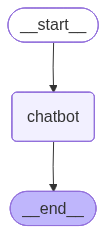

In [ ]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
print("Última respuesta del modelo:")
print(result["messages"][-1].content)

Última respuesta del modelo:
LangGraph es una herramienta que combina el procesamiento del lenguaje natural con grafos para facilitar la comprensión y análisis de relaciones entre conceptos en textos.


## 12. Ejecutar una segunda pregunta

En este ejemplo usaremos manualmente el historial anterior para enviar una nueva pregunta.

Esto ayuda a ver que `messages` puede representar el historial conversacional dentro del estado.

In [ ]:
segunda_ejecucion = graph.invoke({
    "messages": result["messages"] + [
        HumanMessage(content="Ahora explícamelo como si fuera un workflow de negocio.")
    ]
})

imprimir_messages(segunda_ejecucion)

Mensajes en el estado:
------------------------------------------------------------
1. [human] Explícame LangGraph en una frase simple.
2. [ai] LangGraph es una herramienta que combina el procesamiento del lenguaje natural con grafos para facilitar la comprensión y análisis de relaciones entre conceptos en textos.
3. [human] Ahora explícamelo como si fuera un workflow de negocio.
4. [ai] LangGraph se puede entender como un flujo de trabajo en un negocio que sigue estos pasos:

1. **Recopilación de Datos**: Se recolectan textos relevantes, como documentos, correos electrónicos o publicaciones en redes sociales, que contienen información valiosa para la empresa.

2. **Procesamiento del Lenguaje Natural**: Se aplica tecnología de procesamiento del lenguaje natural (NLP) para analizar y extraer entidades, temas y relaciones clave de los textos recopilados.

3. **Construcción de Grafos**: A partir de la información extraída, se construye un grafo que representa visualmente las conexiones en

# Parte B — Ejemplo de negocio

Ahora vamos a llevar la idea a un caso más real.

Imagina que una empresa recibe mensajes de potenciales clientes interesados en una solución de IA.

Queremos construir un workflow simple que haga tres cosas:

1. Analizar el mensaje del cliente.
2. Preparar un contexto de negocio.
3. Generar una respuesta inicial.

Este ejemplo sigue siendo simple, pero ya se parece más a una aplicación real porque no tenemos un solo paso. Tenemos un flujo de responsabilidades.

## 13. Nuevo estado para el caso de negocio

Ahora el estado tendrá más campos.

`messages` seguirá siendo el historial conversacional, pero además agregaremos campos de negocio:

- `tipo_consulta`: qué parece estar solicitando el cliente.
- `producto_detectado`: qué producto o servicio menciona.
- `requiere_humano`: si conviene escalar a una persona.
- `resumen`: contexto preparado para responder.

Esto muestra que `messages` no es todo el estado. Es solo una parte del estado.

In [ ]:
class BusinessState(TypedDict):
    messages: Annotated[list, add_messages]
    tipo_consulta: str
    producto_detectado: str
    requiere_humano: bool
    resumen: str

## 14. Nodo 1: analizar solicitud

Este nodo no llama al modelo.  
Usa reglas simples para identificar información del mensaje.

Esto es importante: un nodo puede llamar un LLM, pero también puede ejecutar lógica de negocio tradicional.

Un nodo representa una responsabilidad, no necesariamente una llamada al modelo.

In [ ]:
def analizar_solicitud(state: BusinessState):
    ultimo_mensaje = state["messages"][-1].content.lower()

    # Detección simple
    if "precio" in ultimo_mensaje or "costo" in ultimo_mensaje or "plan" in ultimo_mensaje:
        tipo_consulta = "consulta_comercial"
    elif "demo" in ultimo_mensaje or "reunión" in ultimo_mensaje or "reunion" in ultimo_mensaje:
        tipo_consulta = "solicitud_demo"
    elif "soporte" in ultimo_mensaje or "error" in ultimo_mensaje:
        tipo_consulta = "soporte"
    else:
        tipo_consulta = "consulta_general"

    if "langgraph" in ultimo_mensaje:
        producto_detectado = "Curso LangGraph desde Cero"
    elif "agente" in ultimo_mensaje or "workflow" in ultimo_mensaje:
        producto_detectado = "Soluciones de agentes y workflows de IA"
    else:
        producto_detectado = "Oferta general de IA"

    requiere_humano = any(
        palabra in ultimo_mensaje
        for palabra in ["enterprise", "contrato", "descuento", "factura", "legal"]
    )

    return {
        "tipo_consulta": tipo_consulta,
        "producto_detectado": producto_detectado,
        "requiere_humano": requiere_humano
    }

## 15. Nodo 2: preparar contexto de negocio

Este nodo toma lo que detectó el nodo anterior y construye un resumen interno.

Ese resumen será usado por el siguiente nodo para responder mejor.

Aquí ya vemos una idea clave de LangGraph:

> Un nodo puede enriquecer el estado para que otro nodo use esa información después.

In [ ]:
def preparar_contexto_negocio(state: BusinessState):
    resumen = (
        f"Tipo de consulta: {state['tipo_consulta']}\n"
        f"Producto detectado: {state['producto_detectado']}\n"
        f"Requiere humano: {state['requiere_humano']}\n"
    )

    if state["requiere_humano"]:
        resumen += (
            "Recomendación: responder de forma inicial y avisar que un asesor humano "
            "puede continuar la conversación."
        )
    else:
        resumen += (
            "Recomendación: responder de forma clara, breve y orientada al siguiente paso."
        )

    return {"resumen": resumen}

## 16. Nodo 3: responder al cliente

Este nodo sí usa el modelo.

Pero observa que el modelo ya no recibe solo el mensaje del usuario.  
También recibe contexto generado por los nodos anteriores.

Esto hace que el workflow sea más controlado:

```text
mensaje del cliente
    ↓
análisis
    ↓
contexto de negocio
    ↓
respuesta
```

In [ ]:
def responder_cliente(state: BusinessState):
    system_prompt = SystemMessage(content="""
Eres un asistente de una empresa que ofrece formación y soluciones de IA.
Responde de forma clara, profesional y cercana.
No inventes precios ni promesas.
Si el caso requiere intervención humana, indícalo de forma natural.
""".strip())

    contexto = HumanMessage(content=f"""
Contexto interno para responder:
{state['resumen']}

Mensaje original del cliente:
{state['messages'][-1].content}

Genera una respuesta inicial para el cliente.
""".strip())

    response = llm.invoke([system_prompt, contexto])

    return {"messages": [response]}

## 17. Construir el grafo de negocio

Ahora nuestro workflow tendrá varios nodos:

```text
START
  ↓
analizar_solicitud
  ↓
preparar_contexto_negocio
  ↓
responder_cliente
  ↓
END
```

Este todavía es un flujo lineal, pero ya muestra responsabilidades separadas.

In [ ]:
business_builder = StateGraph(BusinessState)

business_builder.add_node("analizar_solicitud", analizar_solicitud)
business_builder.add_node("preparar_contexto_negocio", preparar_contexto_negocio)
business_builder.add_node("responder_cliente", responder_cliente)

business_builder.add_edge(START, "analizar_solicitud")
business_builder.add_edge("analizar_solicitud", "preparar_contexto_negocio")
business_builder.add_edge("preparar_contexto_negocio", "responder_cliente")
business_builder.add_edge("responder_cliente", END)

business_graph = business_builder.compile()

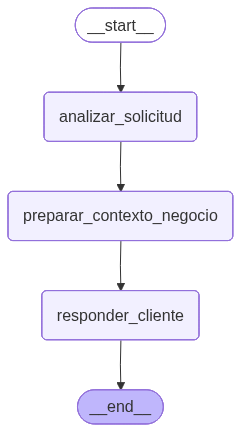

In [ ]:
from IPython.display import Image, display
display(Image(business_graph.get_graph().draw_mermaid_png()))

## 18. Probar el caso de negocio

Vamos a simular un mensaje de un potencial cliente.

Observa que solo enviaremos `messages` al inicio.  
Los demás campos serán completados por los nodos durante la ejecución.

In [ ]:
mensaje_cliente = "Hola, estoy interesado en el curso de LangGraph. ¿Tienen una demo o más información del plan?"

business_result = business_graph.invoke({
    "messages": [
        HumanMessage(content=mensaje_cliente)
    ],
    "tipo_consulta": "",
    "producto_detectado": "",
    "requiere_humano": False,
    "resumen": ""
})

imprimir_messages(business_result)

Mensajes en el estado:
------------------------------------------------------------
1. [human] Hola, estoy interesado en el curso de LangGraph. ¿Tienen una demo o más información del plan?
2. [ai] Hola,

Gracias por tu interés en el curso de LangGraph desde Cero. Actualmente, no ofrecemos una demo, pero con gusto te puedo proporcionar más información sobre el contenido del curso, su duración y los objetivos de aprendizaje.

Si deseas, puedo enviarte un resumen detallado o responder a cualquier pregunta específica que tengas. 

Quedo atento a tu respuesta.

Saludos,  
[Tu Nombre]  
[Tu Cargo]  
[Nombre de la Empresa]  


## 19. Revisar el estado final completo

El resultado final no solo contiene `messages`.

También contiene los campos que los nodos fueron actualizando:

- `tipo_consulta`
- `producto_detectado`
- `requiere_humano`
- `resumen`

Esto es lo que vuelve útil a LangGraph para workflows: no solo genera una respuesta, también permite mantener y transformar estado durante el proceso.

In [ ]:
print("Tipo de consulta:", business_result["tipo_consulta"])
print("Producto detectado:", business_result["producto_detectado"])
print("Requiere humano:", business_result["requiere_humano"])
print("\nResumen interno:")
print(business_result["resumen"])

Tipo de consulta: consulta_comercial
Producto detectado: Curso LangGraph desde Cero
Requiere humano: False

Resumen interno:
Tipo de consulta: consulta_comercial
Producto detectado: Curso LangGraph desde Cero
Requiere humano: False
Recomendación: responder de forma clara, breve y orientada al siguiente paso.


## 20. Conclusiones

Qué debes llevarte de este notebook:

1. **El estado viaja por el grafo.**
2. **Un nodo recibe el estado y devuelve una actualización.**
3. **`messages` es una clave del estado.**
4. **`add_messages` define cómo se acumulan los mensajes.**
5. **Un nodo no es todo el agente; es una responsabilidad dentro del workflow.**
6. **Un workflow real suele tener más campos que solo `messages`.**
7. **LangGraph permite separar responsabilidades para que la solución sea más clara y mantenible.**
